# Atelier Seaborn Contexte
 Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression, la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure. Après avoir utilisé NumPy pour manipuler les données numériques, Pandas pour importer, nettoyer et analyser le dataset et Matplotlib pour réaliser des visualisations, l'étape suivante consiste à se servir de Seaborn pour réaliser une analyse exploratoire plus riche des données. 

# 
2) Stocker le fichier fourni mesures_capteurs.csv dans le sous-dossier data 
3) Créer le notebook atelier_seaborn_iot.ipynb 
4) Installer et importer seaborn, matplotlib, pandas, numpy 
5) Importer mesures_capteurs.csv dans le dataframe df 
6) Vérifier le contenu du dataframe df 

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")


In [3]:
sns.__version__

'0.13.2'

In [4]:
# 5) Importer mesures_capteurs.csv dans le dataframe df 
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [5]:
df.shape

(605, 9)

In [6]:
df.ndim

2

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


# Partie 1 – Distribution d'une variable avec histplot()
 1) Afficher la distribution des températures 
 2) Autour de quelle valeur les températures sont concentrées ? 
 3) La distribution semble-t-elle symétrique ? 
 4) Existe-t-il des valeurs extrêmes ? 
 5) Modifier le nombre de classes 
 6) Afficher la distribution des températures par bâtiment

##  1) Afficher la distribution des températures 

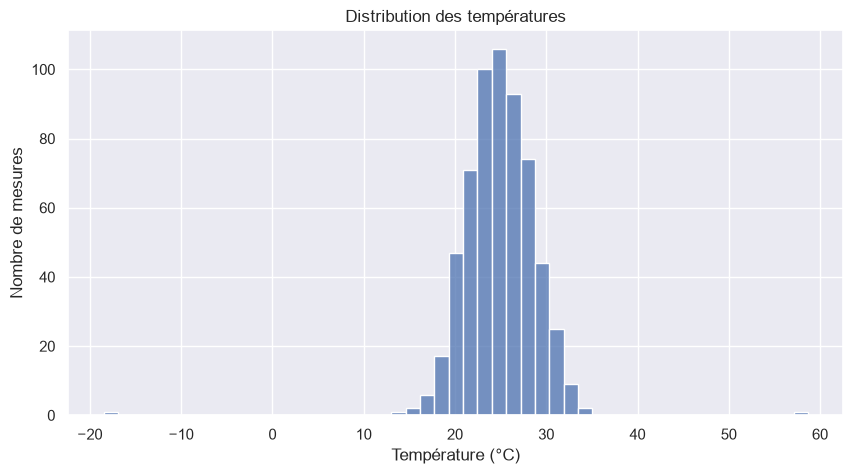

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="temperature" )
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.show()

##  2) Autour de quelle valeur les températures sont concentrées ? 
 Les températures se concentrent autour de ~25°C, là où le pic de l'histogramme (et de la 
courbe KDE) est le plus haut

##  3) La distribution semble-t-elle symétrique ? 
 La distribution semble symétrique la courbe KDE dessine une forme de cloche assez 
régulière, montant puis redescendant de façon comparable de part et d'autre du pic.

##  4) Existe-t-il des valeurs extrêmes ? 
 Oui — on voit deux petites barres quasi invisibles, isolées loin du pic principal : une vers 
-20°C, une vers 58°C. Un grand espace vide les sépare du reste de la distribution.

## 5) Modifier le nombre de classes 

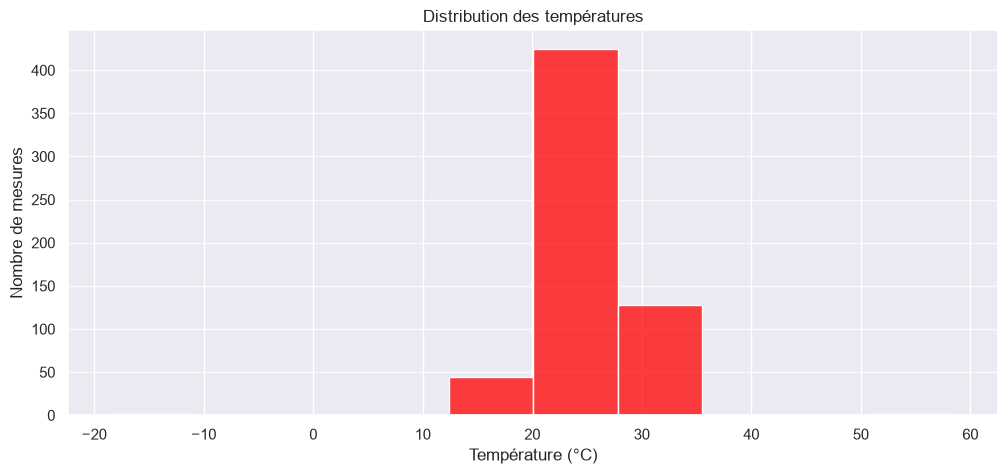

In [32]:
plt.figure(figsize=(12, 5))

sns.histplot(data=df, x="temperature" , bins=10, color="red")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.grid(axis='y', alpha=0.75)
plt.show()



Avec 10 classes, on ne distingue plus clairement que 3 grandes barres (autour de 15-20°C, 
20-28°C, et 28-35°C) — les valeurs aberrantes autour de -18.5°C et 58.7°C, bien que 
techniquement présentes, sont écrasées à la fois par leur position isolée et par leur 
hauteur minuscule comparée au pic central. Avec 20 ou 30 classes (vu précédemment), ces 
valeurs isolées restent tout aussi invisibles, pour la même raison. Réduire le nombre de 
classes rend la forme générale plus lisse mais fait perdre en détail sur la répartition 
précise des mesures centrales.

## 6) Afficher la distribution des températures par bâtiment


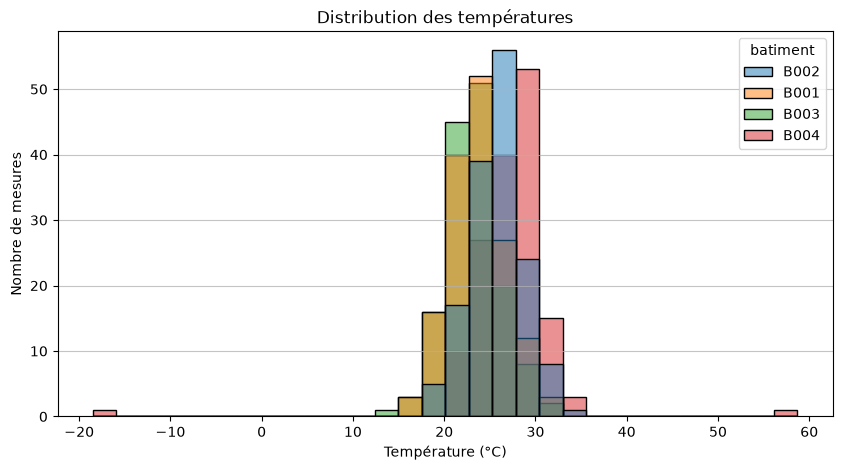

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="temperature" , bins=30,hue="batiment", color="red")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.grid(axis='y', alpha=0.75)
plt.show()



Les 4 bâtiments montrent des distributions globalement similaires et superposées autour du 
pic central (20-30°C) — pas de différence marquante dans leur comportement normal. En 
revanche, les deux valeurs extrêmes déjà identifiées (vers -18°C et 58°C) sont toutes les 
deux colorées en rose, donc appartiennent au même bâtiment : B004. Cela confirme l'hypothèse 
déjà formulée dans l'atelier Matplotlib — B004 semble avoir un capteur ou un système 
présentant un dysfonctionnement récurrent, distinct des trois autres bâtiments.